In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
generation_data = pd.read_csv('/content/Plant_1_Generation_Data (1).csv')
weather_data = pd.read_csv('/content/Plant_2_Weather_Sensor_Data (1).csv')

In [ ]:
generation_data.sample(5)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
41483,05-06-2020 00:15,4135001,7JYdWkrLSPkdwr4,0.000,0.0000,0.00,7756621.00
15463,23-05-2020 03:15,4135001,YxYtjZvoooNbGkE,0.000,0.0000,0.00,7236121.00
38924,03-06-2020 18:30,4135001,3PZuoBAID5Wc2HD,98.125,9.4625,7873.75,7136487.75
62475,14-06-2020 23:45,4135001,bvBOhCH3iADSZry,0.000,0.0000,1979.00,6521600.00
42399,05-06-2020 10:30,4135001,uHbuxQJl8lW7ozc,9137.875,892.9625,2104.75,7196639.75


In [ ]:
weather_data.sample(5)

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
1293,2020-05-28 11:45:00,4136001,iq8k7ZNt4Mwm3w0,33.304609,55.940556,0.937421
251,2020-05-17 15:00:00,4136001,iq8k7ZNt4Mwm3w0,36.109529,45.677039,0.301377
1676,2020-06-01 11:45:00,4136001,iq8k7ZNt4Mwm3w0,30.702195,39.678808,0.485910
818,2020-05-23 13:00:00,4136001,iq8k7ZNt4Mwm3w0,35.962772,58.698998,0.887755
475,2020-05-19 23:15:00,4136001,iq8k7ZNt4Mwm3w0,23.484847,21.763375,0.000000


In [ ]:
generation_data['DATE_TIME'] = pd.to_datetime(generation_data['DATE_TIME'], errors='coerce')
weather_data['DATE_TIME'] = pd.to_datetime(weather_data['DATE_TIME'], errors='coerce')

/tmp/ipykernel_7221/576185362.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation_data['DATE_TIME'] = pd.to_datetime(generation_data['DATE_TIME'], errors='coerce')


In [ ]:
merge_table = pd.merge(generation_data, weather_data, on='DATE_TIME')
merge_table.sample(5)

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
23967,2020-05-27 07:00:00,4135001,1IF53ai7Xc0U56Y,2124.250,208.262500,98.250000,6274736.250,4136001,iq8k7ZNt4Mwm3w0,26.345867,28.121515,0.144763
14683,2020-05-22 17:45:00,4135001,1IF53ai7Xc0U56Y,531.875,51.450000,7270.375000,6240517.375,4136001,iq8k7ZNt4Mwm3w0,36.012593,36.652407,0.091366
21326,2020-05-26 00:30:00,4135001,McdE0feGgRqW7Ca,0.000,0.000000,0.000000,7241649.000,4136001,iq8k7ZNt4Mwm3w0,26.956658,27.155379,0.000000
32743,2020-05-31 20:15:00,4135001,7JYdWkrLSPkdwr4,0.000,0.000000,5843.000000,7727821.000,4136001,iq8k7ZNt4Mwm3w0,25.864434,24.365258,0.000886
53439,2020-06-10 17:45:00,4135001,zVJPv84UY57bAof,1197.000,116.414286,6531.428571,7316987.429,4136001,iq8k7ZNt4Mwm3w0,27.759774,25.464606,0.007683


In [ ]:
merge_table.isnull().sum()

,0
DATE_TIME,0
PLANT_ID_x,0
SOURCE_KEY_x,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0
PLANT_ID_y,0
SOURCE_KEY_y,0
AMBIENT_TEMPERATURE,0


In [ ]:
merge_table.describe()

,DATE_TIME,PLANT_ID_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,68708,68708.0,68708.000000,68708.000000,68708.000000,6.870800e+04,68708.0,68708.000000,68708.000000,68708.000000
mean,2020-06-01 08:09:31.269721344,4135001.0,3145.740142,307.637345,3292.746206,6.978761e+06,4136001.0,28.095600,32.976117,0.238832
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,4136001.0,20.942385,20.265123,0.000000
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512031e+06,4136001.0,24.602479,23.738608,0.000000
50%,2020-06-01 14:30:00,4135001.0,422.267857,40.814286,2647.196428,7.146685e+06,4136001.0,27.063545,27.788045,0.030336
75%,2020-06-09 20:15:00,4135001.0,6359.459822,622.977679,6272.169643,7.268800e+06,4136001.0,31.067282,40.821388,0.448928
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,4136001.0,39.181638,66.635953,1.098766
std,NaN,0.0,4037.184118,394.466485,3145.069221,4.162738e+05,0.0,4.072488,11.406764,0.314324


Data Visualization:

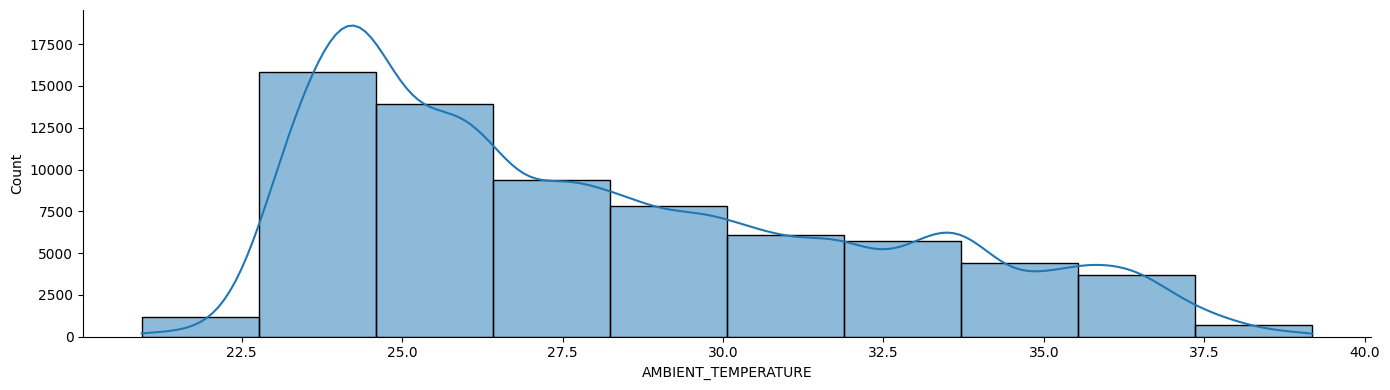

In [ ]:
sns.displot(data = merge_table, x = "AMBIENT_TEMPERATURE", kde=True, bins = 10, height = 4, aspect = 3.5);

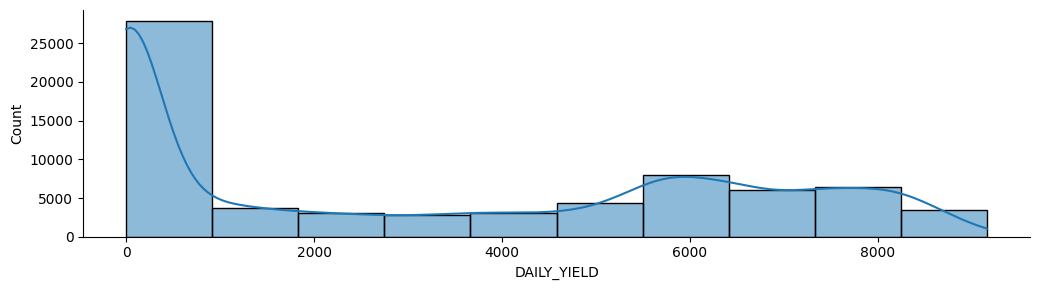

In [ ]:
sns.displot(data = merge_table, x = "DAILY_YIELD", kde=True, bins = 10, height = 3, aspect = 3.5);

Please upload the required CSV files ('Plant_1_Generation_Data.csv' and 'Plant_2_Weather_Sensor_Data.csv') to your Colab environment.

In [ ]:
merge_table['DATE_TIME'].nunique()

3154


Faults & Abnormalities detection in solar power plant generation

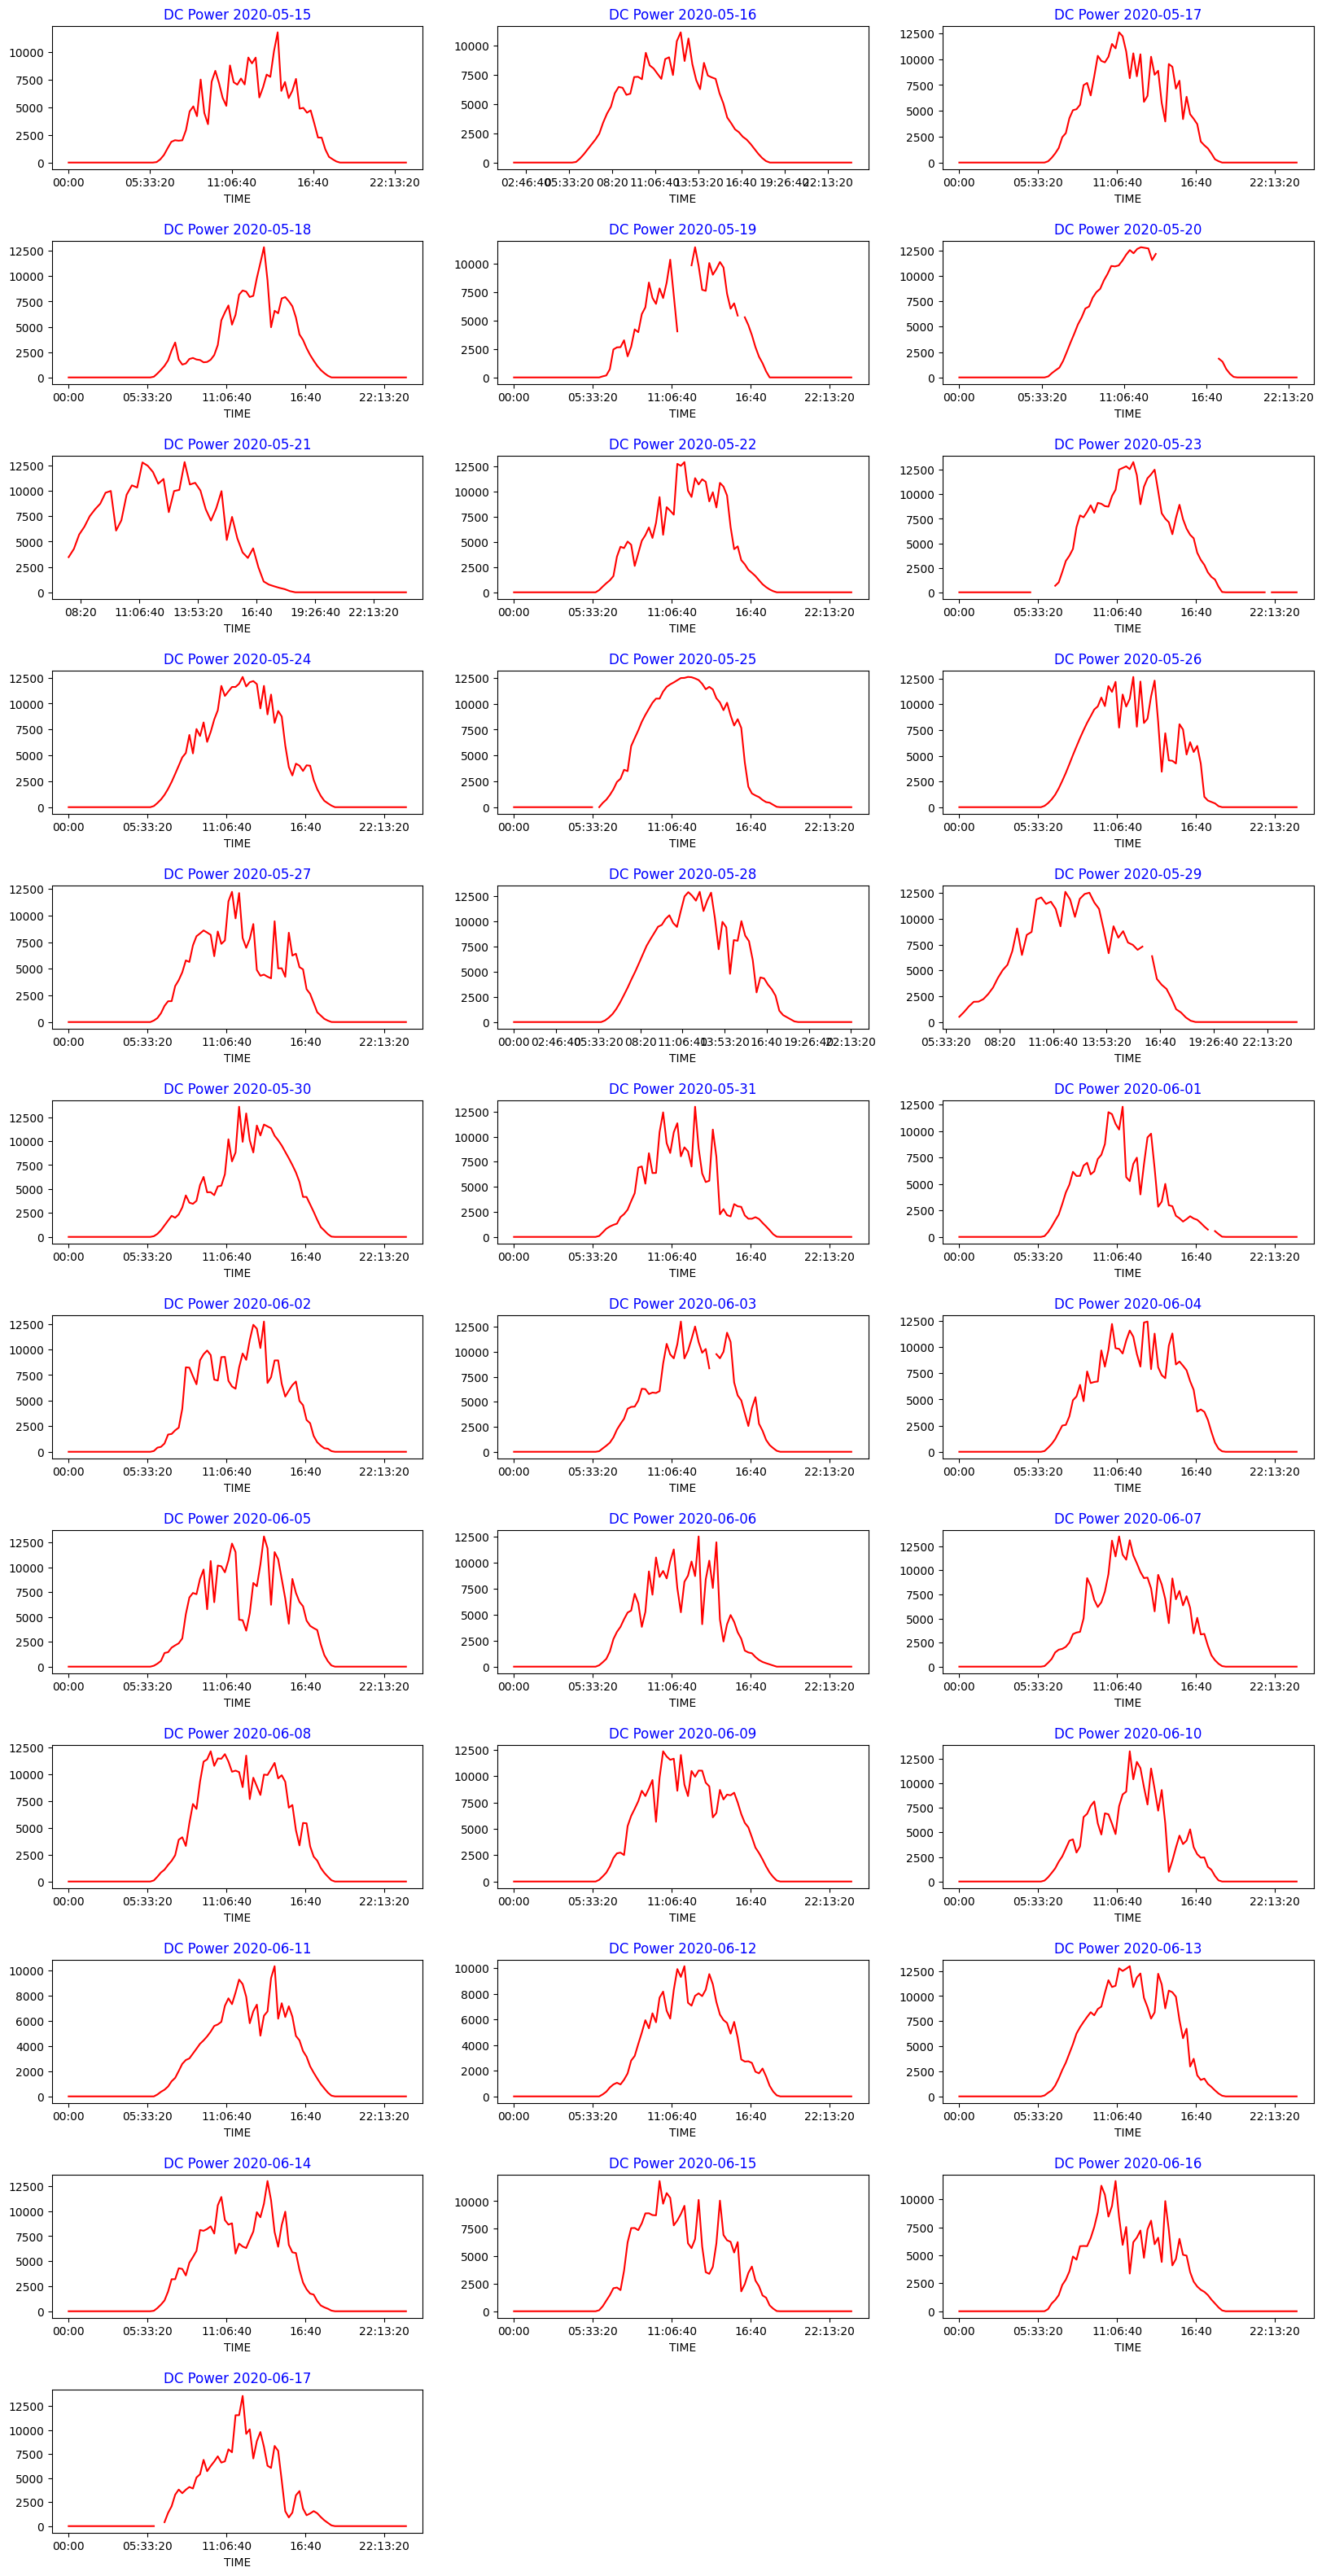

In [ ]:
merge_table['DATE'] = merge_table['DATE_TIME'].dt.date
merge_table['TIME'] = merge_table['DATE_TIME'].dt.time
solar_dc = merge_table.pivot_table(values='DC_POWER', index='TIME', columns='DATE')
def Daywise_plot(data=None, row=None, col=None, title='DC Power'  ):
    cols = data.columns
    gp = plt.figure(figsize=(20, 40))
    gp.subplots_adjust(wspace=0.2, hspace=0.5)
    if row * col < len(cols):
        raise ValueError(f"Row*Col ({row*col}) is less than number of columns ({len(cols)}).")
    for i in range(1, len(cols) + 1):
        ax = gp.add_subplot(row, col, i)
        data[cols[i - 1]].plot(ax=ax, color='red')
        ax.set_title(f'{title} {cols[i - 1]}', color='blue')
    plt.show()
Daywise_plot(data=solar_dc, row=12, col=3)

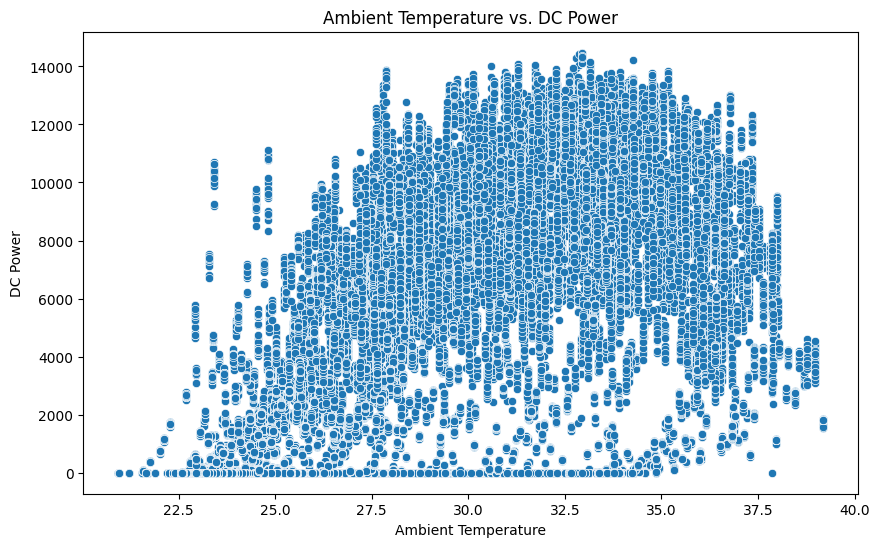

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merge_table, x='AMBIENT_TEMPERATURE', y='DC_POWER')
plt.title('Ambient Temperature vs. DC Power')
plt.xlabel('Ambient Temperature')
plt.ylabel('DC Power')
plt.show()

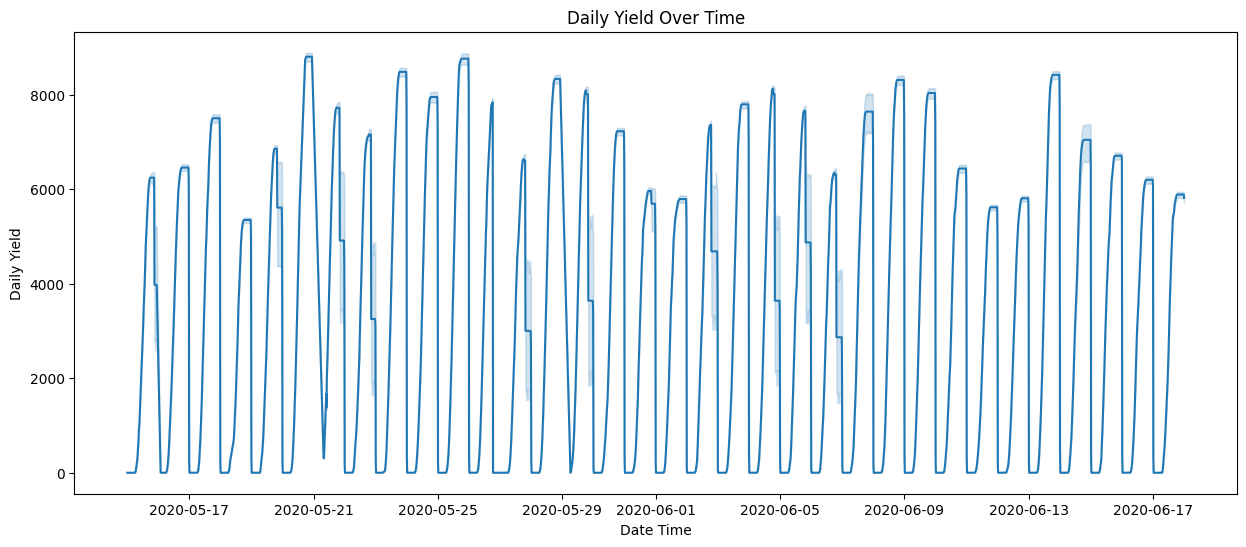

In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=merge_table, x='DATE_TIME', y='DAILY_YIELD')
plt.title('Daily Yield Over Time')
plt.xlabel('Date Time')
plt.ylabel('Daily Yield')
plt.show()

Solar Power Plant Inverter Efficiency Calculation

In [ ]:
solar_dc_power = merge_table[merge_table['DC_POWER'] > 0]['DC_POWER'].values
solar_ac_power = merge_table[merge_table['AC_POWER'] > 0]['AC_POWER'].values

In [ ]:
solar_plant_eff = (np.max(solar_ac_power)/np.max(solar_dc_power ))*100
print(f"Power ratio AC/DC (Efficiency) of Solar Power Plant:  {solar_plant_eff:0.3f} %")

Power ratio AC/DC (Efficiency) of Solar Power Plant:  9.750 %


Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split

X = merge_table.drop(['DAILY_YIELD', 'DATE_TIME', 'SOURCE_KEY_x',
                      'SOURCE_KEY_y', 'DATE', 'TIME'], axis=1)
y = merge_table['DAILY_YIELD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

# New Section

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

R2_lr = round(r2_score(y_test, y_pred_lr) * 100, 2)
print("Linear Regression R2 Score:", R2_lr, "%")

Linear Regression R2 Score: 39.05 %


Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rfr = RandomForestRegressor(random_state=21)
rfr.fit(X_train, y_train)

y_pred_rfr = rfr.predict(X_test)

R2_rfr = round(r2_score(y_test, y_pred_rfr) * 100, 2)
print("Random Forest R2 Score:", R2_rfr, "%")

Random Forest R2 Score: 94.46 %


DecisionTree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dtr = DecisionTreeRegressor(random_state=21)
dtr.fit(X_train, y_train)

y_pred_dtr = dtr.predict(X_test)

R2_dtr = round(r2_score(y_test, y_pred_dtr) * 100, 2)
print("Decision Tree R2 Score:", R2_dtr, "%")

Decision Tree R2 Score: 90.85 %


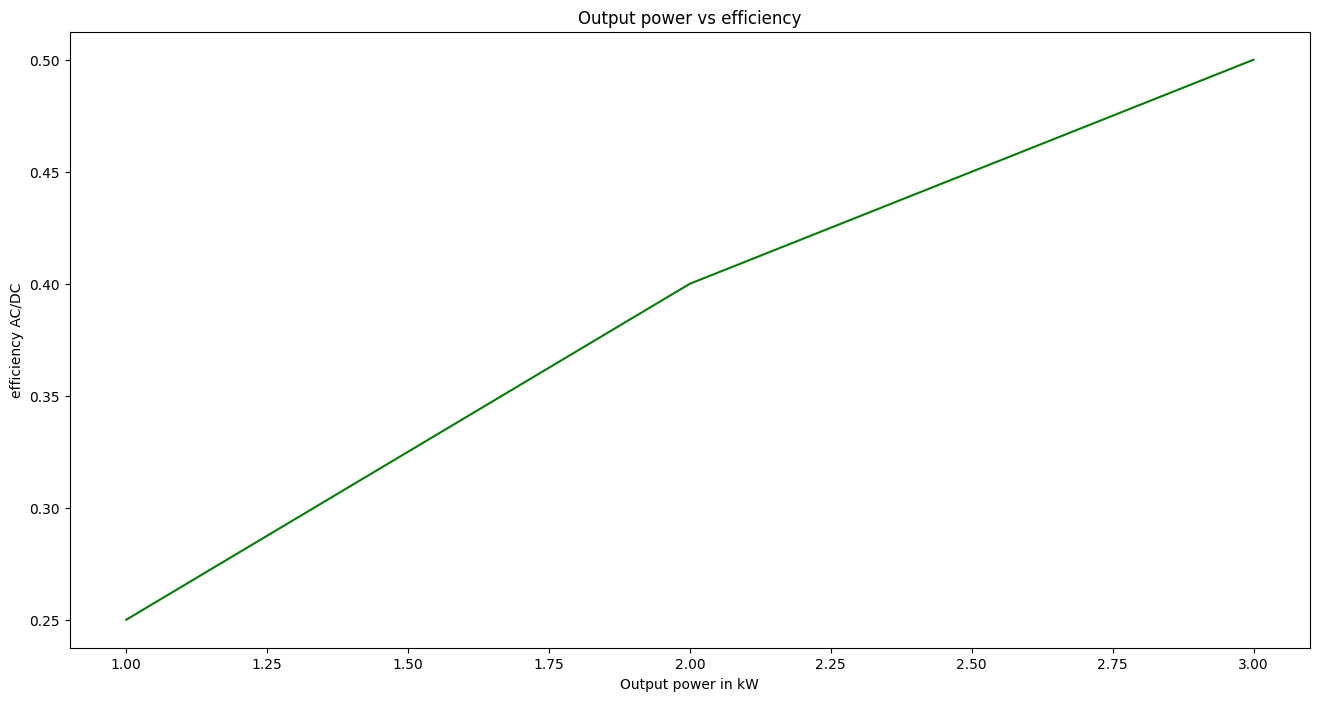

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
AC_list= [1,2,3]
DC_list= [4,5,6]
AC_list.sort()
DC_list.sort()
eff = [i/j for i,j in zip(AC_list,DC_list)]

plt.plot(AC_list, eff, color='green')
plt.xlabel('Output power in kW')
plt.ylabel('efficiency AC/DC')
plt.title('Output power vs efficiency');


New Parameters included

In [ ]:
# ==============================
# 3. FEATURE ENGINEERING
# ==============================

# Using 'merge_table' instead of 'df'
# Time features
merge_table['hour'] = merge_table['DATE_TIME'].dt.hour
merge_table['day'] = merge_table['DATE_TIME'].dt.day
merge_table['month'] = merge_table['DATE_TIME'].dt.month

# Cyclical encoding (important)
merge_table['hour_sin'] = np.sin(2 * np.pi * merge_table['hour'] / 24)
merge_table['hour_cos'] = np.cos(2 * np.pi * merge_table['hour'] / 24)

# Lag features
merge_table['lag_1'] = merge_table['AC_POWER'].shift(1)
merge_table['lag_2'] = merge_table['AC_POWER'].shift(2)
merge_table['lag_24'] = merge_table['AC_POWER'].shift(24)

# Drop missing values
merge_table = merge_table.dropna()

In [ ]:
# ==============================
# 4. SELECT FEATURES
# ==============================
features = [
    'IRRADIATION',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'hour_sin',
    'hour_cos',
    'lag_1',
    'lag_2',
    'lag_24'
]

target = 'AC_POWER'

# Using 'merge_table' instead of 'df'
data = merge_table[features + [target]]

In [ ]:
# ==============================
# 5. NORMALIZATION
# ==============================
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
# ==============================
# 6. CREATE SEQUENCES
# ==============================
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps, :-1])
        y.append(data[i+time_steps, -1])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, time_steps=24)


In [ ]:
# ==============================
# 7. TRAIN-TEST SPLIT
# ==============================
split = int(0.8 * len(X))

X_train_lstm, X_test_lstm = X[:split], X[split:]
y_train_lstm, y_test_lstm = y[:split], y[split:]

In [ ]:
# ==============================
# 8. BUILD LSTM MODEL
# ==============================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 24, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,825 (210.25 KB)

 Trainable params: 53,825 (210.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================
# 9. TRAIN MODEL
# ==============================
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
1545/1545 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - loss: 0.0038 - val_loss: 0.0013
Epoch 2/5
1545/1545 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 3/5
1545/1545 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 4/5
1545/1545 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - loss: 0.0024 - val_loss: 0.0013
Epoch 5/5
1545/1545 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - loss: 0.0024 - val_loss: 0.0013


In [ ]:
# ==============================
# 10. PREDICTION
# ==============================
predictions = model.predict(X_test_lstm)

430/430 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step


In [ ]:
# ==============================
# 11. INVERSE SCALING
# ==============================
dummy = np.zeros((len(predictions), scaled_data.shape[1]))

# Predicted
dummy[:, -1] = predictions[:, 0]
predicted_power = scaler.inverse_transform(dummy)[:, -1]

# Actual
dummy = np.zeros((len(y_test_lstm), scaled_data.shape[1]))
dummy[:, -1] = y_test_lstm
actual_power = scaler.inverse_transform(dummy)[:, -1]

In [ ]:
# ==============================
# 12. EVALUATION
# ==============================
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual_power, predicted_power))
mae = mean_absolute_error(actual_power, predicted_power)

print("RMSE (Root Mean Squared Error):", rmse)
print("MAE (Mean Absolute Error):", mae)

RMSE (Root Mean Squared Error): 64.35501466656683
MAE (Mean Absolute Error): 26.114691006660294


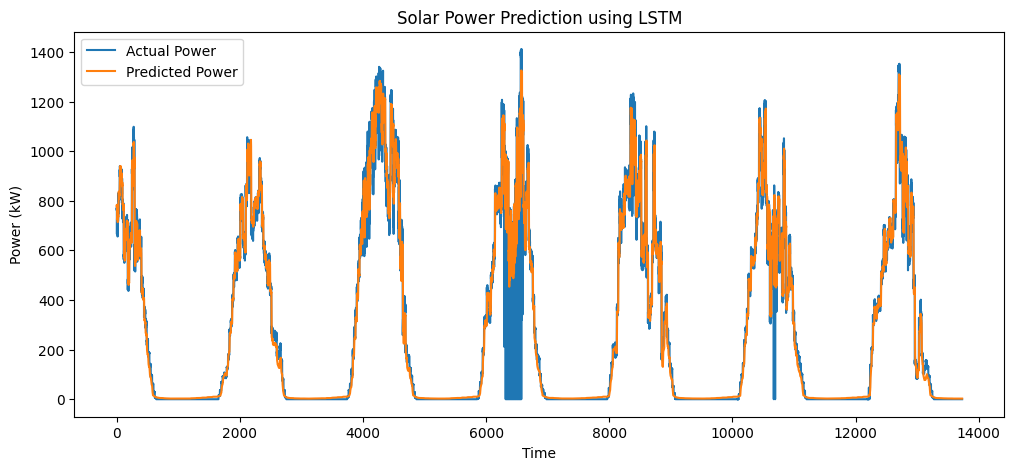

In [ ]:
# ==============================
# 13. VISUALIZATION
# ==============================
plt.figure(figsize=(12,5))
plt.plot(actual_power, label='Actual Power')
plt.plot(predicted_power, label='Predicted Power')
plt.legend()
plt.title("Solar Power Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.show()